# 01 - Análise Exploratória dos Dados (EDA)

**Datathon Educação — Passos Mágicos**

Neste notebook, realizamos a análise exploratória do dataset PEDE (Pesquisa Extensiva de Desenvolvimento Educacional) da Associação Passos Mágicos, abrangendo os períodos de 2020, 2021 e 2022.

---

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from src.utils import (
    NUMERIC_INDICATORS, YEARS, PEDRA_MAP, DATA_RAW_DIR,
    generate_synthetic_data, load_raw_data
)

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Carregamento dos Dados

Tentamos carregar os dados reais do diretório `data/raw/`. Caso não estejam disponíveis, utilizamos dados sintéticos que seguem o mesmo schema do dataset PEDE.

In [2]:
try:
    df = load_raw_data()
    print(f'Dados reais carregados.')
except FileNotFoundError:
    df = generate_synthetic_data(n_samples=500)
    print('Usando dados sinteticos (coloque o CSV PEDE em data/raw/ para dados reais).')

print(f'Shape: {df.shape}')
print(f'Colunas: {len(df.columns)}')
df.head()

2026-02-28 20:48:53.171 | INFO     | src.utils:load_raw_data:102 - Arquivo detectado: PEDE_PASSOS_DATASET_FIAP.csv
2026-02-28 20:48:54.250 | INFO     | src.utils:load_raw_data:113 - Carregados 1349 registros, 69 colunas de PEDE_PASSOS_DATASET_FIAP.csv


Dados reais carregados.
Shape: (1349, 69)
Colunas: 69


,INSTITUICAO_ENSINO_ALUNO_2020,NOME,IDADE_ALUNO_2020,ANOS_PM_2020,FASE_TURMA_2020,PONTO_VIRADA_2020,INDE_2020,INDE_CONCEITO_2020,PEDRA_2020,DESTAQUE_IEG_2020,...,IPP_2022,REC_AVA_1_2022,REC_AVA_2_2022,REC_AVA_3_2022,REC_AVA_4_2022,INDICADO_BOLSA_2022,PONTO_VIRADA_2022,IPV_2022,IAN_2022,NIVEL_IDEAL_2022
0,Escola Pública,ALUNO-1,11,2,2H,Não,7.883752,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,ALUNO-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.625000,Mantido na Fase + Bolsa,Mantido na Fase atual,NaN,NaN,Sim,Não,7.916665,5.0,Fase 2 (5º e 6º ano)
2,Escola Pública,ALUNO-3,12,2,3H,Não,7.856389666666666,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Escola Pública,ALUNO-4,10,2,1D,Não,5.076252,D,Quartzo,Ponto a melhorar em 2021: Melhorar a sua entre...,...,6.250000,Promovido de Fase,Mantido na Fase atual,Promovido de Fase,NaN,Não,Não,8.055553,5.0,Fase 3 (7º e 8º ano)
4,Escola Pública,ALUNO-5,10,1,2M,Não,8.077085,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,6.458333,Mantido na Fase atual,Promovido de Fase,Mantido na Fase atual,NaN,Não,Não,7.833337,5.0,Fase 3 (7º e 8º ano)


## 2. Visão Geral do Dataset

In [3]:
print('=== Informacoes do Dataset ===')
print(f'Registros: {len(df)}')
print(f'Colunas: {len(df.columns)}')
print(f'Valores nulos totais: {df.isnull().sum().sum()}')
print(f'% nulos: {df.isnull().mean().mean():.2%}')
print()
print('=== Tipos de dados ===')
print(df.dtypes.value_counts())

=== Informacoes do Dataset ===
Registros: 1349
Colunas: 69
Valores nulos totais: 40493
% nulos: 43.50%

=== Tipos de dados ===
object     43
float64    26
Name: count, dtype: int64


In [4]:
df.describe().round(2)

,FASE_2021,IAA_2021,IEG_2021,IPS_2021,IDA_2021,IPP_2021,IPV_2021,IAN_2021,DEFASAGEM_2021,FASE_2022,...,IEG_2022,IPS_2022,IDA_2022,NOTA_PORT_2022,NOTA_MAT_2022,NOTA_ING_2022,QTD_AVAL_2022,IPP_2022,IPV_2022,IAN_2022
count,686.00,686.00,686.00,686.00,686.00,686.00,686.00,686.00,686.00,862.00,...,862.00,862.00,862.00,860.00,860.00,285.00,862.00,862.00,862.00,862.00
mean,2.28,8.15,6.82,6.84,5.43,7.58,7.41,6.90,-0.75,2.11,...,7.88,6.90,6.07,5.80,6.31,5.84,3.06,6.30,7.25,6.42
std,1.80,2.19,2.46,1.46,2.14,1.07,1.63,2.48,0.79,1.80,...,1.65,1.07,2.06,2.42,2.09,2.99,0.78,1.14,1.10,2.39
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.50,-4.00,0.00,...,0.00,2.50,0.00,0.00,0.00,0.00,2.00,0.00,2.50,2.50
25%,1.00,7.90,5.30,6.90,4.10,7.30,6.60,5.00,-1.00,1.00,...,7.00,6.25,4.75,4.32,5.17,3.50,2.00,5.62,6.72,5.00
50%,2.00,8.80,7.20,7.50,5.85,7.70,7.70,5.00,-1.00,2.00,...,8.31,7.50,6.33,6.00,6.65,6.27,3.00,6.25,7.33,5.00
75%,3.00,9.50,8.80,7.50,6.90,8.10,8.60,10.00,0.00,3.00,...,9.10,7.50,7.58,7.83,7.83,8.50,4.00,7.03,7.92,10.00
max,7.00,10.00,10.00,8.80,9.50,10.00,10.00,10.00,3.00,7.00,...,10.00,10.00,9.92,10.00,10.00,10.00,4.00,9.22,10.00,10.00


## 3. Análise de Valores Ausentes

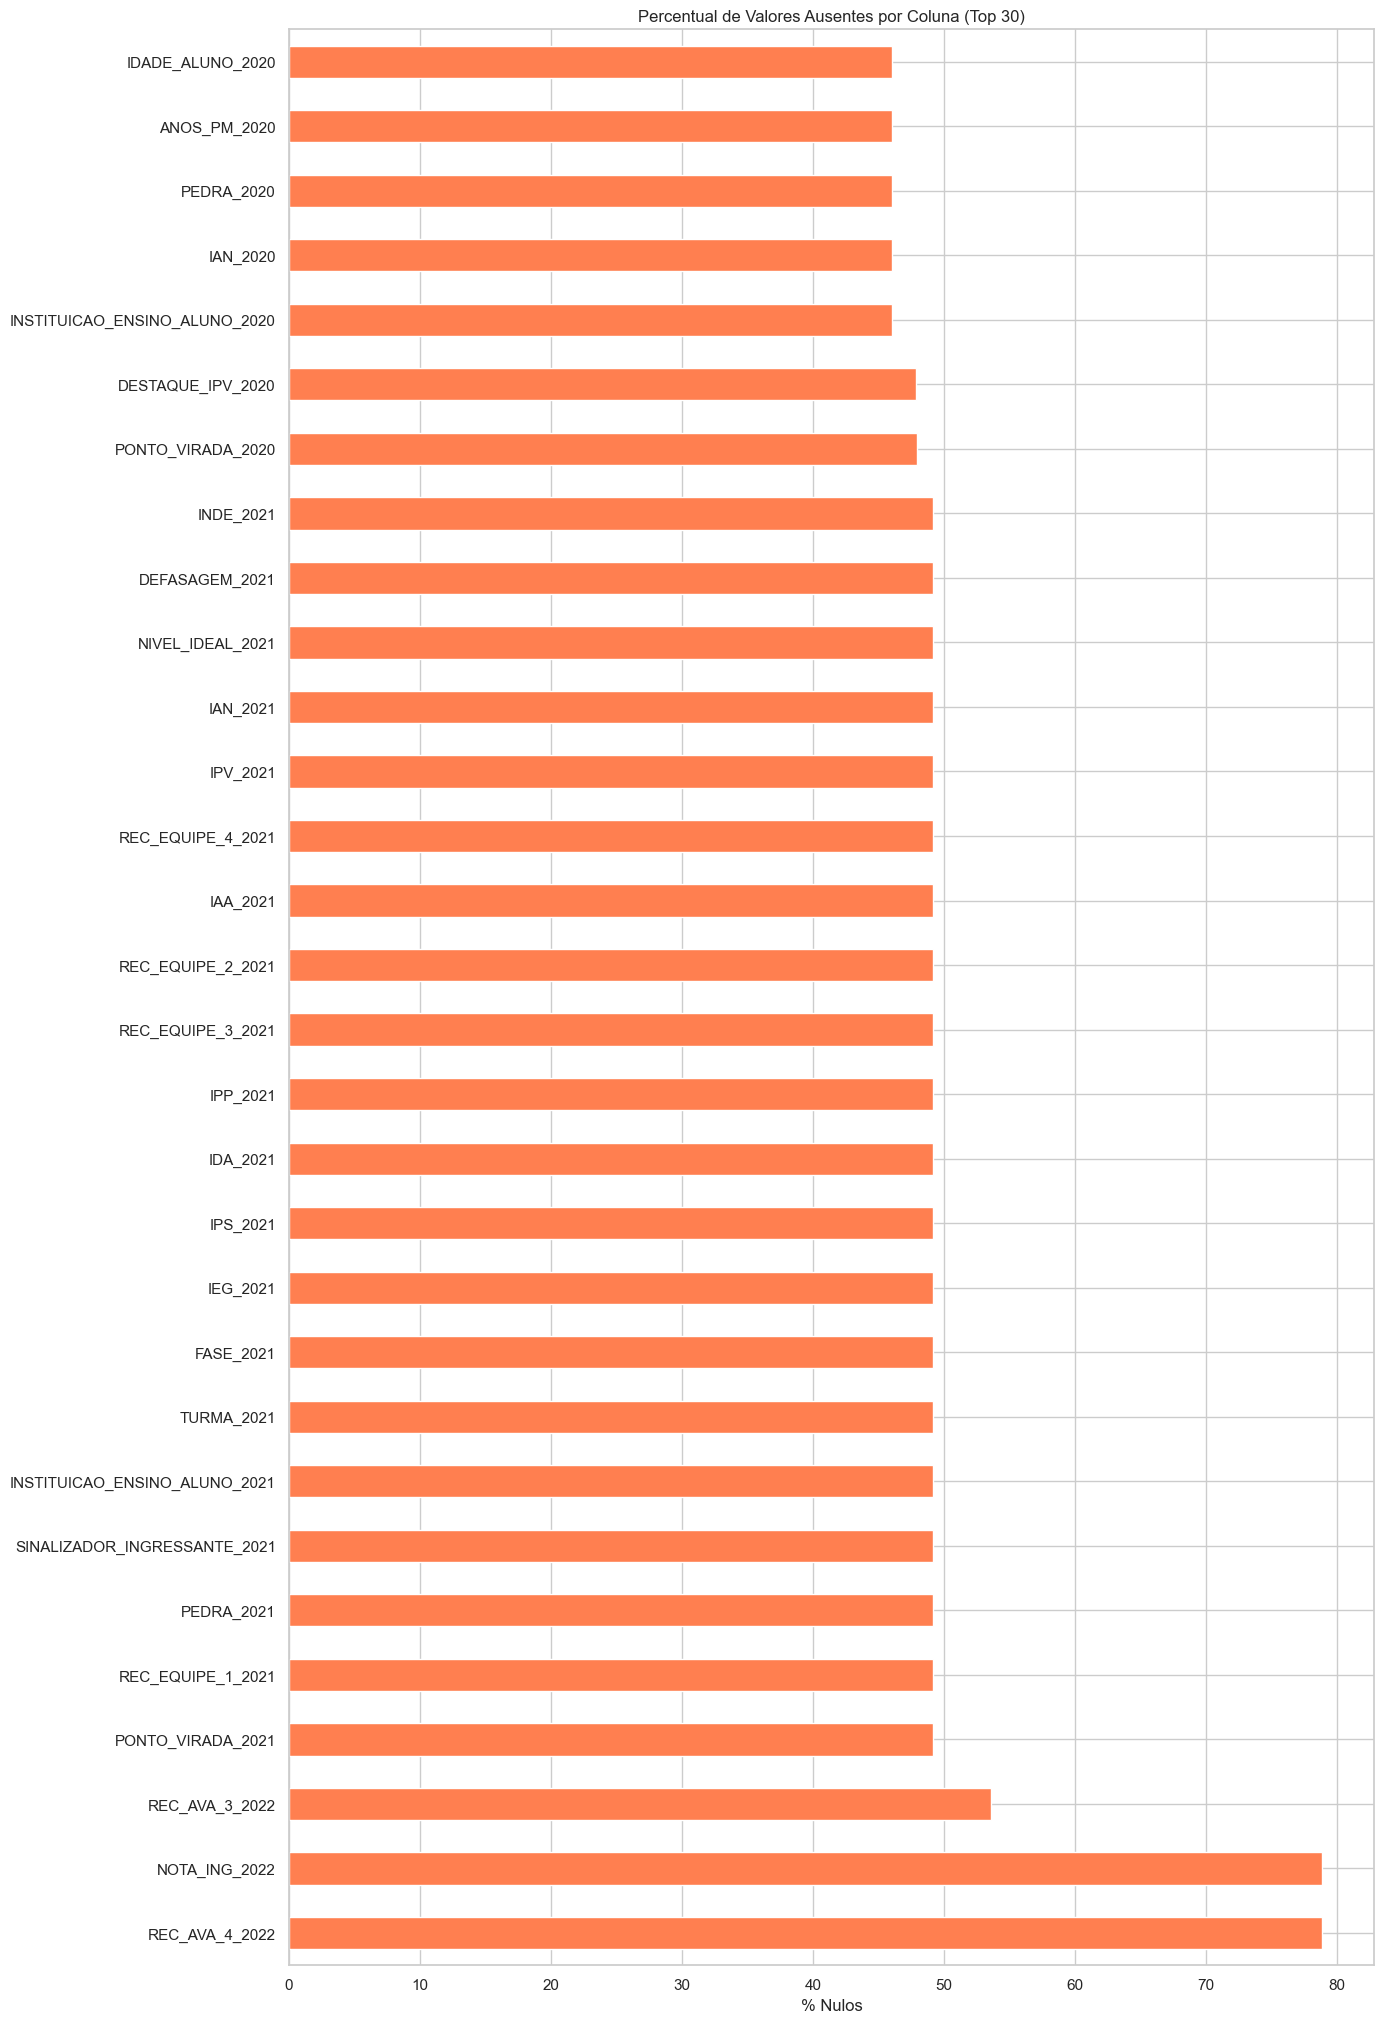

In [5]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

if len(null_pct) > 0:
    fig, ax = plt.subplots(figsize=(14, max(5, len(null_pct) * 0.3)))
    null_pct.head(30).plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('% Nulos')
    ax.set_title('Percentual de Valores Ausentes por Coluna (Top 30)')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum valor ausente encontrado.')

## 4. Distribuição dos Indicadores Educacionais

Os indicadores PEDE medem diferentes dimensões do desenvolvimento dos estudantes:
- **INDE**: Índice de Desenvolvimento Educacional
- **IAA**: Indicador de Autoavaliação
- **IEG**: Indicador de Engajamento
- **IPS**: Indicador Psicossocial
- **IDA**: Indicador de Adequação de Nível
- **IPP**: Indicador Psicopedagógico
- **IAN**: Indicador de Adequação de Nível
- **IPV**: Indicador do Ponto de Virada

TypeError: can only concatenate str (not "int") to str

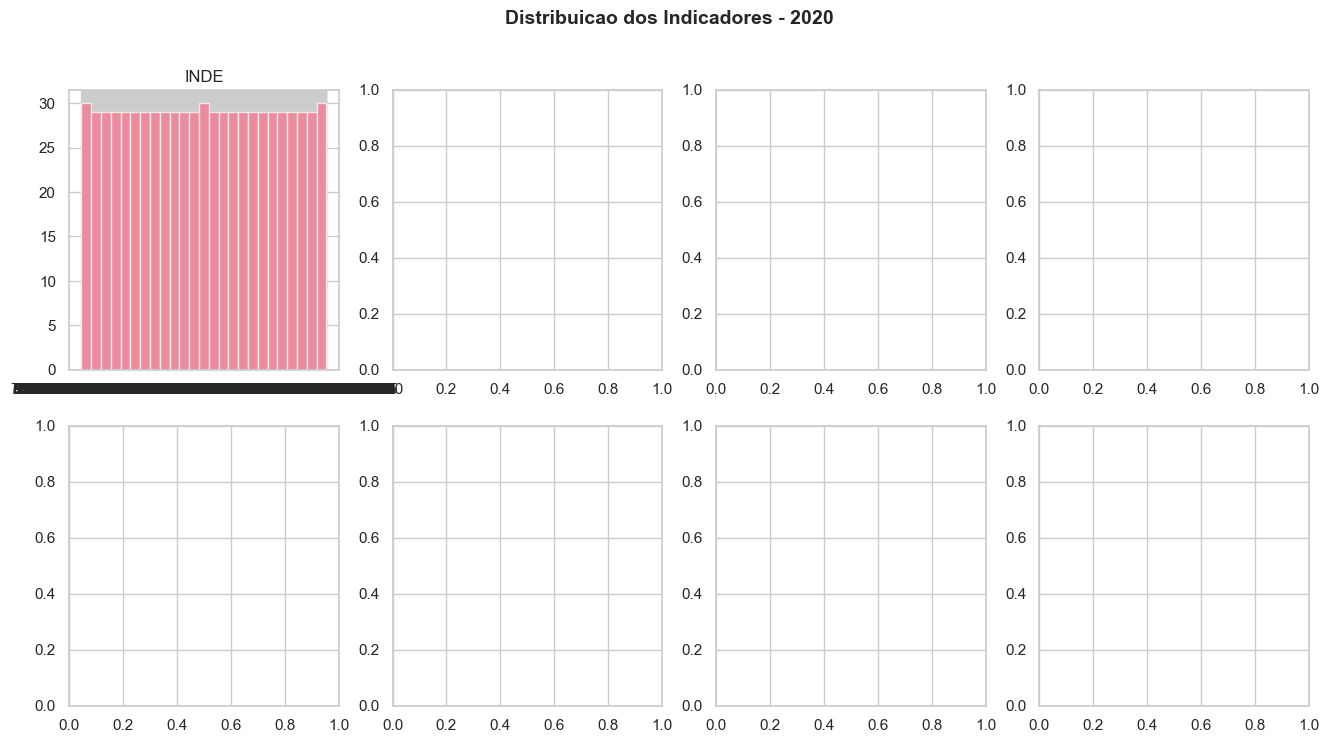

In [6]:
latest_year = max(YEARS)

for year in YEARS:
    cols = [f'{ind}_{year}' for ind in NUMERIC_INDICATORS if f'{ind}_{year}' in df.columns]
    if cols:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        fig.suptitle(f'Distribuicao dos Indicadores - {year}', fontsize=14, fontweight='bold')
        for i, col in enumerate(cols[:8]):
            ax = axes[i // 4, i % 4]
            df[col].dropna().hist(bins=25, ax=ax, color=sns.color_palette('husl', 8)[i], alpha=0.7)
            ax.set_title(col.replace(f'_{year}', ''))
            ax.axvline(df[col].mean(), color='red', linestyle='--', alpha=0.7, label=f'media={df[col].mean():.1f}')
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

## 5. Boxplots Comparativos

In [7]:
for year in YEARS:
    cols = [f'{ind}_{year}' for ind in NUMERIC_INDICATORS if f'{ind}_{year}' in df.columns]
    if cols:
        plot_df = df[cols].melt(var_name='Indicador', value_name='Valor')
        plot_df['Indicador'] = plot_df['Indicador'].str.replace(f'_{year}', '')

        fig = px.box(plot_df, x='Indicador', y='Valor', color='Indicador',
                     title=f'Distribuicao dos Indicadores - {year}')
        fig.update_layout(showlegend=False)
        fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 6. Matriz de Correlação

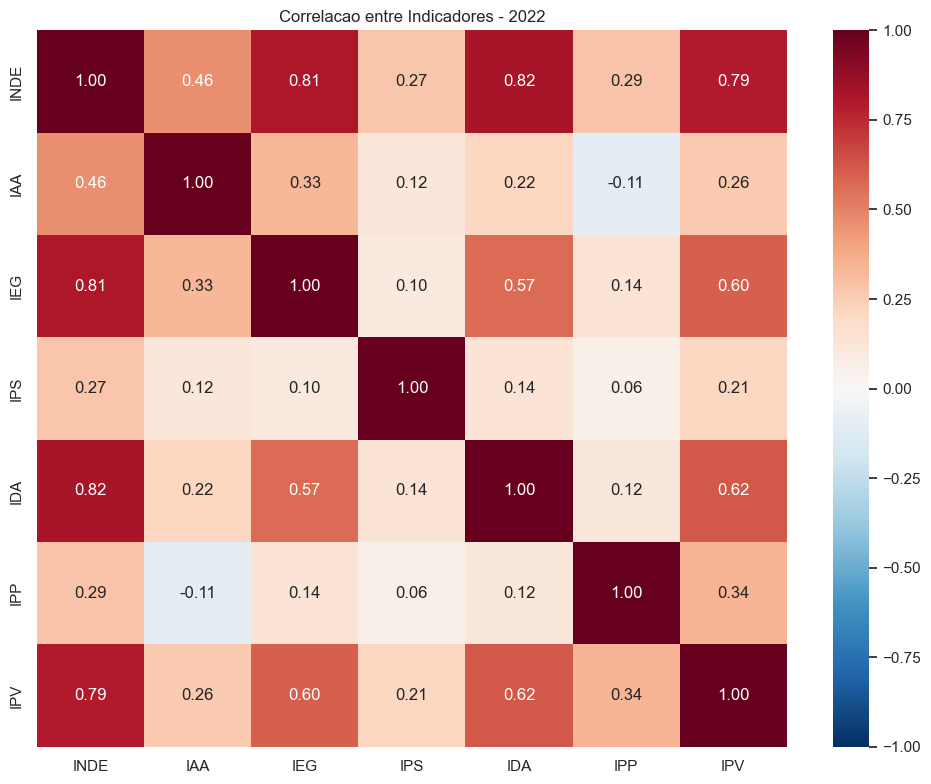


=== Correlacoes mais fortes (positivas) ===
  INDE x IDA: 0.821
  INDE x IEG: 0.805
  INDE x IPV: 0.792
  IDA x IPV: 0.622
  IEG x IPV: 0.595


In [8]:
corr_cols = [f'{ind}_{latest_year}' for ind in NUMERIC_INDICATORS if f'{ind}_{latest_year}' in df.columns]

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    labels = [c.replace(f'_{latest_year}', '') for c in corr_cols]

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'Correlacao entre Indicadores - {latest_year}')
    plt.tight_layout()
    plt.show()

    print('\n=== Correlacoes mais fortes (positivas) ===')
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    top_corr = upper.stack().sort_values(ascending=False).head(5)
    for (c1, c2), val in top_corr.items():
        print(f'  {c1.replace(f"_{latest_year}", "")} x {c2.replace(f"_{latest_year}", "")}: {val:.3f}')

## 7. Evolução Temporal dos Indicadores

In [9]:
means = {}
for year in YEARS:
    year_means = {}
    for ind in NUMERIC_INDICATORS:
        col = f'{ind}_{year}'
        if col in df.columns:
            year_means[ind] = df[col].mean()
    means[year] = year_means

means_df = pd.DataFrame(means).T
means_df.index.name = 'Ano'

fig = px.line(means_df.reset_index(), x='Ano', y=means_df.columns.tolist(),
              title='Evolucao da Media dos Indicadores (2020-2022)',
              markers=True)
fig.update_layout(yaxis_title='Media', legend_title='Indicador')
fig.show()

print('\n=== Medias por Ano ===')
means_df.round(2)

TypeError: can only concatenate str (not "int") to str

## 8. Classificação PEDRA

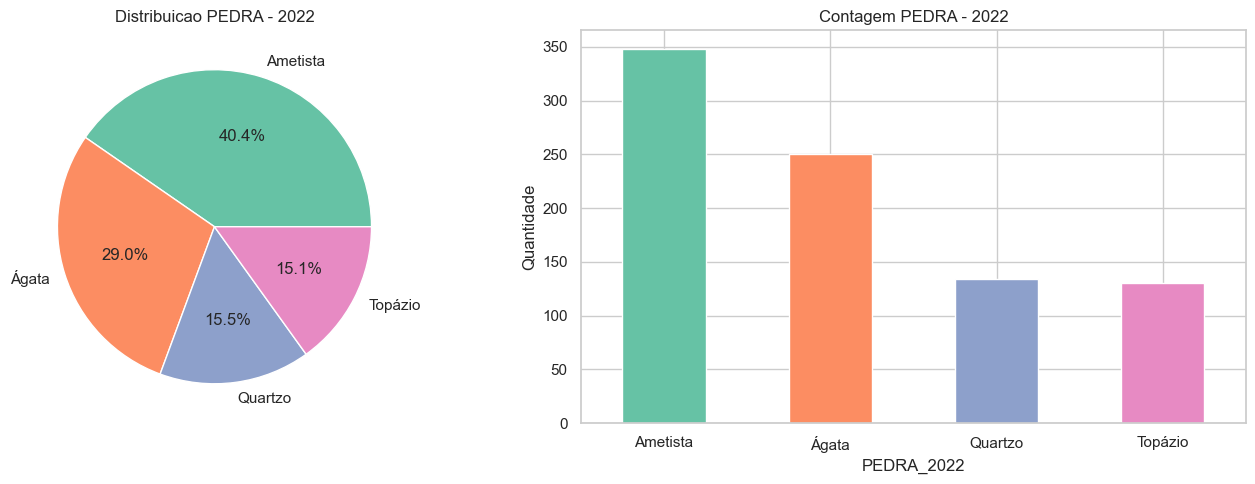

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [10]:
pedra_col = f'PEDRA_{latest_year}'
if pedra_col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    counts = df[pedra_col].value_counts()
    axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('Set2', len(counts)))
    axes[0].set_title(f'Distribuicao PEDRA - {latest_year}')

    counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', len(counts)))
    axes[1].set_title(f'Contagem PEDRA - {latest_year}')
    axes[1].set_ylabel('Quantidade')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    inde_col = f'INDE_{latest_year}'
    if inde_col in df.columns:
        fig = px.box(df, x=pedra_col, y=inde_col, color=pedra_col,
                     title=f'INDE por Classificacao PEDRA - {latest_year}',
                     category_orders={pedra_col: list(PEDRA_MAP.keys())})
        fig.show()

## 9. Variável Alvo: Defasagem

In [11]:
target_col = f'DEFASAGEM_{latest_year}'

if target_col in df.columns:
    target = df[target_col].dropna().astype(int)
    counts = target.value_counts().sort_index()
    label_map = {0: 'Sem Risco', 1: 'Em Risco'}

    print('=== Distribuicao da Variavel Alvo ===')
    for val, count in counts.items():
        print(f'  {label_map.get(val, val)}: {count} ({count/len(target):.1%})')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].pie(counts.values, labels=[label_map.get(i, str(i)) for i in counts.index],
                autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
    axes[0].set_title(f'Defasagem - {latest_year}')

    inde_col = f'INDE_{latest_year}'
    if inde_col in df.columns:
        for val in sorted(target.unique()):
            data = df.loc[target == val, inde_col].dropna()
            axes[1].hist(data, bins=25, alpha=0.6, label=label_map.get(val, str(val)))
        axes[1].set_xlabel('INDE')
        axes[1].set_ylabel('Frequencia')
        axes[1].set_title(f'INDE por Defasagem - {latest_year}')
        axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print(f'Coluna {target_col} nao encontrada no dataset.')

Coluna DEFASAGEM_2022 nao encontrada no dataset.


## 10. Conclusões da EDA

**Principais achados:**

1. **Indicadores**: Os indicadores PEDE (INDE, IAA, IEG, etc.) seguem distribuições aproximadamente normais na escala 0-10.

2. **Correlações**: Indicadores acadêmicos (INDE, IAA, IDA) tendem a ser correlacionados entre si, sugerindo que alunos com bom desempenho em uma dimensão também performam bem em outras.

3. **Evolução temporal**: A análise longitudinal (2020-2022) permite identificar tendências de melhoria ou deterioração nos indicadores.

4. **PEDRA**: A classificação PEDRA (Quartzo → Topázio) reflete o nível de desenvolvimento do aluno, com forte correlação com o INDE.

5. **Defasagem**: A variável alvo mostra desbalanceamento moderado entre classes, justificando o uso de `class_weight='balanced'` e F1-Score como métrica principal.

---

**Próximo passo**: Notebook `02_Pipeline_ML.ipynb` — Pipeline de Machine Learning